# Red card and shots on target

Shot columns in `combined_data.csv`:

* **HS**: home shots, every shot
* **AS**: away shots, every shot
* **HST**: home shots on target, aimed at the goal
* **AST**: away shots on target, aimed at the goal

A shot on target is not a goal. Goals are `FTHG` and `FTAG`. A red card is `HR` for the home side and `AR` for the away side.


In [1]:
import pandas as pd

df = pd.read_csv("combined_data.csv")


## Reds by referee and club

Each row is one referee and one club they actually officiated, home and away together. Rows with 0 reds are left out. A single red stays. A referee and club who met in only one match are left out. **Club usual** is that club's reds per match with every referee.

In [8]:
home = df[["Referee", "HomeTeam", "HR"]].rename(columns={"HomeTeam": "Team", "HR": "reds"})
away = df[["Referee", "AwayTeam", "AR"]].rename(columns={"AwayTeam": "Team", "AR": "reds"})
long = pd.concat([home, away], ignore_index=True)

team_rate = long.groupby("Team")["reds"].mean()
pair = long.groupby(["Referee", "Team"]).agg(matches=("reds", "size"), reds=("reds", "sum"))
pair["reds per match"] = pair["reds"] / pair["matches"]
pair["club usual"] = pair.index.get_level_values("Team").map(team_rate)
pair = pair[(pair["reds"] >= 1) & (pair["matches"] > 1)].sort_values(["reds", "matches"], ascending=[False, False])
'''to view the full table remove "#" in line below '''
#pd.set_option("display.max_rows", None)
print("Reds per match in total:", round(long["reds"].mean(), 3))
pair.round(3)

Reds per match in total: 0.058


matches  reds  reds per match  club usual
Referee     Team                                                       
M Oliver    Everton                29     7           0.241       0.079
            Arsenal                31     4           0.129       0.083
            Tottenham              22     4           0.182       0.064
A Taylor    Arsenal                26     3           0.115       0.083
C Pawson    Newcastle              23     3           0.130       0.045
...                               ...   ...             ...         ...
L Smith     Burnley                 2     1           0.500       0.058
M Salisbury Chelsea                 2     1           0.500       0.071
            Sheffield United        2     1           0.500       0.088
P Tierney   Sunderland              2     1           0.500       0.079
R Jones     Ipswich                 2     1           0.500       0.132

[223 rows x 4 columns]

The clearest pair is **M Oliver** and **Everton**: 7 reds in 29 matches, above Everton's usual rate. The same referee has 4 reds for Tottenham and 4 for Arsenal. Several other referees reach 3 reds with one club. A single red stays in the table, but that row alone is not a pattern.

## Shots per goal by club, with and without a red

Each row is one club. **No red** is that club's matches with no red card. **Red** is the matches where that club was shown a red. **Shots per goal** is how many shots they took for each goal they scored.

In [3]:
home = df[["HomeTeam", "HS", "HST", "FTHG", "HR"]].rename(
    columns={"HomeTeam": "Team", "HS": "shots", "HST": "sot", "FTHG": "goals", "HR": "reds"}
)
away = df[["AwayTeam", "AS", "AST", "FTAG", "AR"]].rename(
    columns={"AwayTeam": "Team", "AS": "shots", "AST": "sot", "FTAG": "goals", "AR": "reds"}
)
side = pd.concat([home, away], ignore_index=True)

rows = []
for team, s in side.groupby("Team"):
    red = s[s["reds"] > 0]
    none = s[s["reds"] == 0]
    if red["goals"].sum() == 0 or none["goals"].sum() == 0:
        continue
    rows.append({
        "Team": team,
        "Red matches": len(red),
        "Shots per goal, no red": none["shots"].sum() / none["goals"].sum(),
        "Shots per goal, red": red["shots"].sum() / red["goals"].sum(),
        "On target per goal, no red": none["sot"].sum() / none["goals"].sum(),
        "On target per goal, red": red["sot"].sum() / red["goals"].sum(),
    })

by_team = pd.DataFrame(rows).sort_values("Red matches", ascending=False)
by_team.round(2)

,Team,Red matches,"Shots per goal, no red","Shots per goal, red","On target per goal, no red","On target per goal, red"
0,Arsenal,21,7.64,10.14,2.62,3.52
8,Everton,19,10.20,12.80,3.51,3.93
6,Chelsea,19,8.83,9.92,3.15,3.67
26,Wolves,18,10.28,11.19,3.43,4.50
25,West Ham,16,8.35,15.70,2.88,4.60
4,Brighton,15,9.95,9.79,3.40,3.32
22,Tottenham,15,7.45,9.53,2.81,3.33
7,Crystal Palace,14,9.51,11.40,3.30,3.60
1,Aston Villa,14,8.54,9.40,3.02,3.47
14,Man City,12,7.32,7.29,2.66,2.52


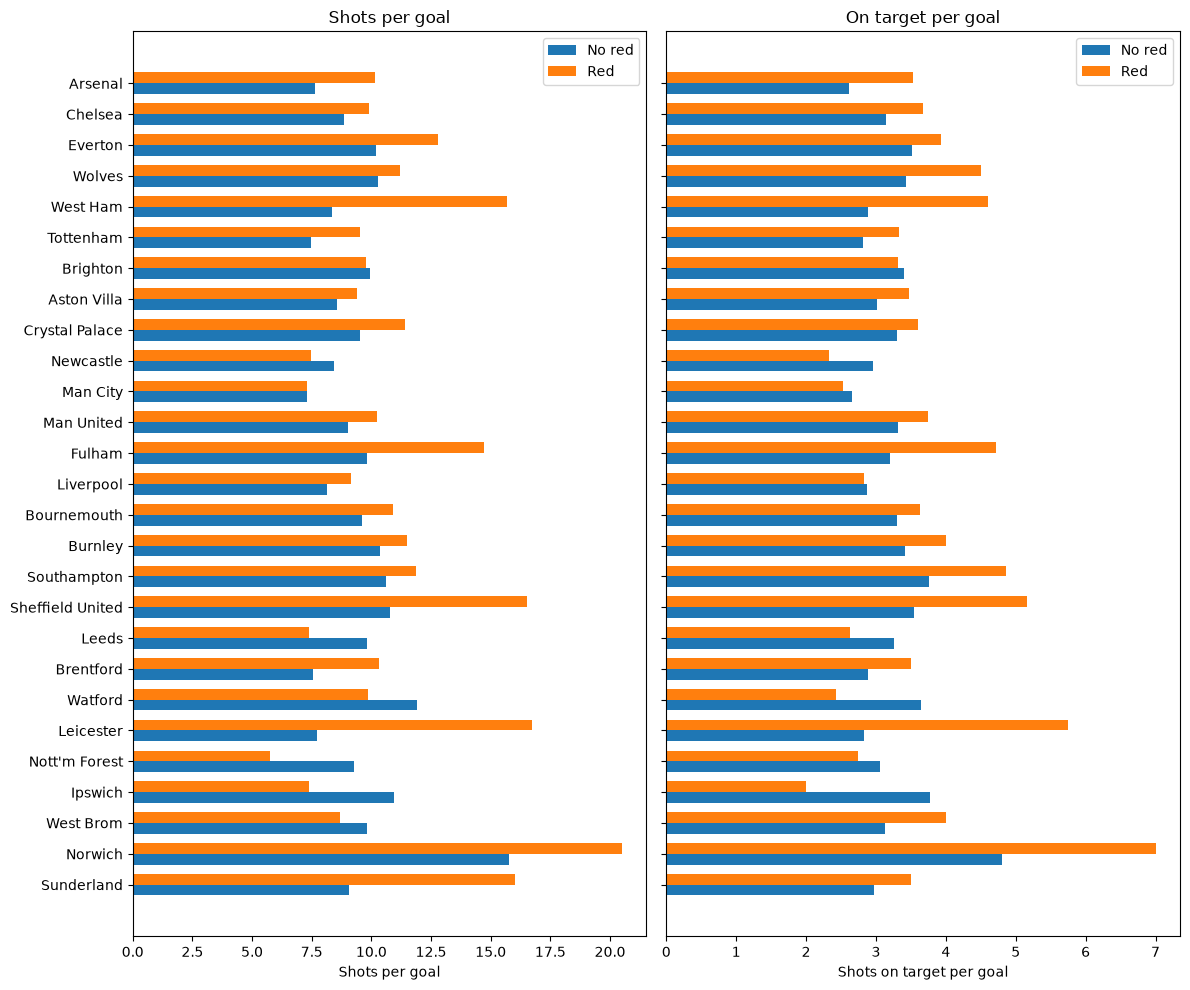

In [5]:
import matplotlib.pyplot as plt

plot = by_team.sort_values("Red matches", ascending=True)
y = range(len(plot))
h = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 10), sharey=True)

axes[0].barh([i - h / 2 for i in y], plot["Shots per goal, no red"], height=h, label="No red")
axes[0].barh([i + h / 2 for i in y], plot["Shots per goal, red"], height=h, label="Red")
axes[0].set_xlabel("Shots per goal")
axes[0].set_title("Shots per goal")
axes[0].legend()

axes[1].barh([i - h / 2 for i in y], plot["On target per goal, no red"], height=h, label="No red")
axes[1].barh([i + h / 2 for i in y], plot["On target per goal, red"], height=h, label="Red")
axes[1].set_xlabel("Shots on target per goal")
axes[1].set_title("On target per goal")
axes[1].legend()

axes[0].set_yticks(list(y))
axes[0].set_yticklabels(plot["Team"])
fig.tight_layout()
plt.show()


A red means most clubs need more shots, and more shots on target, for each goal. Across all clubs, shots per goal go from about 9 to about 10, and on target per goal from about 3 to about 3.5. Arsenal goes from about 8 to about 10 shots, and from about 2.6 to about 3.5 on target. West Ham goes from about 8 to about 16 shots, and from about 3 to about 4.6 on target. Fulham moves the same way. Man City stays flat on both. Clubs with only a few red matches can jump either way.

In [6]:
sot = df["HST"] - df["AST"]
home_red = df["HR"] > 0
away_red = df["AR"] > 0

def result_pct(mask):
    g = df.loc[mask, "FTR"]
    pct = (g.value_counts(normalize=True) * 100).reindex(["H", "D", "A"]).fillna(0)
    return pd.Series({
        "n": int(mask.sum()),
        "Home win": pct["H"],
        "Draw": pct["D"],
        "Away win": pct["A"],
    })

rows = {
    "Home more on target, no home red": (sot > 0) & ~home_red,
    "Home more on target, home red": (sot > 0) & home_red,
    "Away more on target, no away red": (sot < 0) & ~away_red,
    "Away more on target, away red": (sot < 0) & away_red,
}
table = pd.DataFrame({name: result_pct(mask) for name, mask in rows.items()}).T
table.round(1)


,n,Home win,Draw,Away win
"Home more on target, no home red",1357.0,65.5,20.6,13.9
"Home more on target, home red",46.0,41.3,28.3,30.4
"Away more on target, no away red",960.0,17.3,23.8,59.0
"Away more on target, away red",34.0,23.5,41.2,35.3
